In [1]:
"""
Modelo para la prediccion del valor de casas
"""


import pandas as pd

data = pd.read_csv("Casas-California.csv")

data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [2]:
#obteniendo valor de una columna especifica
data["ocean_proximity"].value_counts()

<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: ocean_proximity, dtype: int64

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [4]:
data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

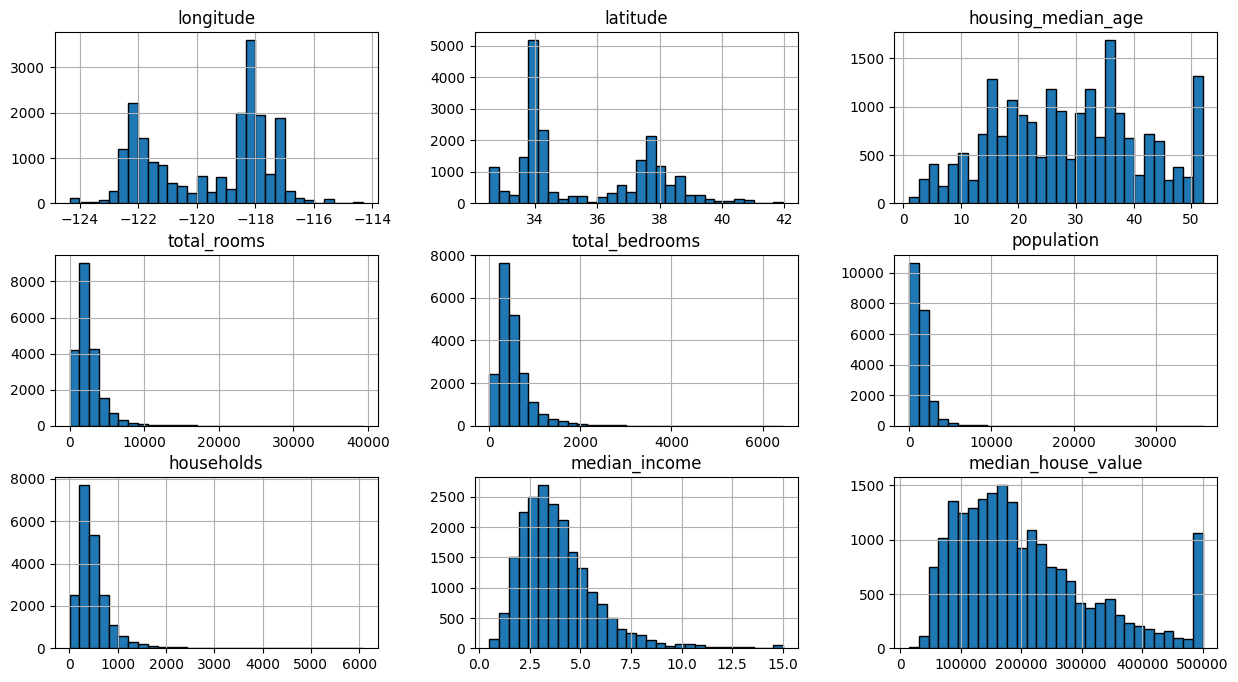

In [5]:
data.hist(figsize=(15,8), bins=30 , edgecolor="black")

<Axes: xlabel='longitude', ylabel='latitude'>

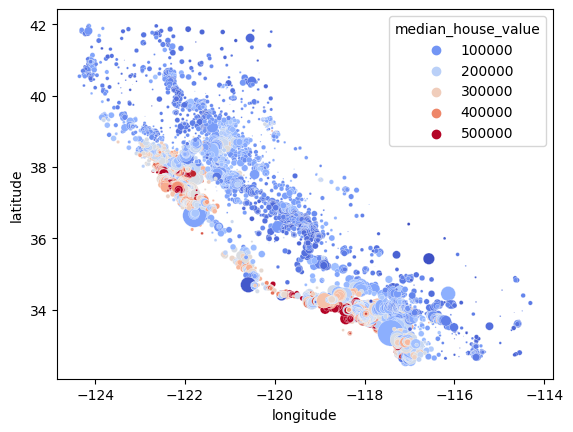

In [6]:

import seaborn as sb
sb.scatterplot(x='longitude' , y='latitude' , data=data, hue='median_house_value' , palette='coolwarm', s=data["population"]/100)

<Axes: xlabel='longitude', ylabel='latitude'>

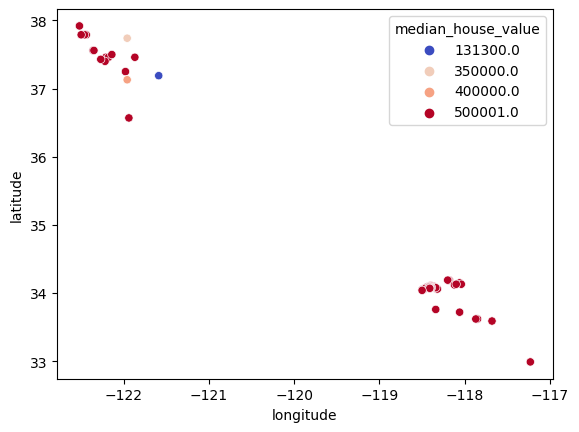

In [7]:
# filtro de datos -> muestra donde vive la gente que gana mas

sb.scatterplot(x='longitude' , y='latitude' , data=data[data.median_income > 14], hue='median_house_value' , palette='coolwarm')

In [8]:
#limpiando datos vacios

datos_na= data.dropna()
datos_na

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [9]:
#convertir las caracteristicas categoricas a numericas
#proximidad al oceano
datos_na["ocean_proximity"].value_counts()


<1H OCEAN     9034
INLAND        6496
NEAR OCEAN    2628
NEAR BAY      2270
ISLAND           5
Name: ocean_proximity, dtype: int64

In [10]:
#dummies / one hot encoding
# nearbay island near ocean
#  1        0      0

dummies = pd.get_dummies(datos_na["ocean_proximity"], dtype=int)
# datos_na= datos_na.join(dummies)
datos_na

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [11]:
# axis hace referencia a las columnas

datos_na = datos_na.drop(["ocean_proximity"], axis=1)
datos_na

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0
...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0


<ipython-input-12-cab985ad14b4>:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  data.corr()
<ipython-input-12-cab985ad14b4>:8: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sb.heatmap(data.corr(), annot=True, cmap="YlGnBu")


<Axes: >

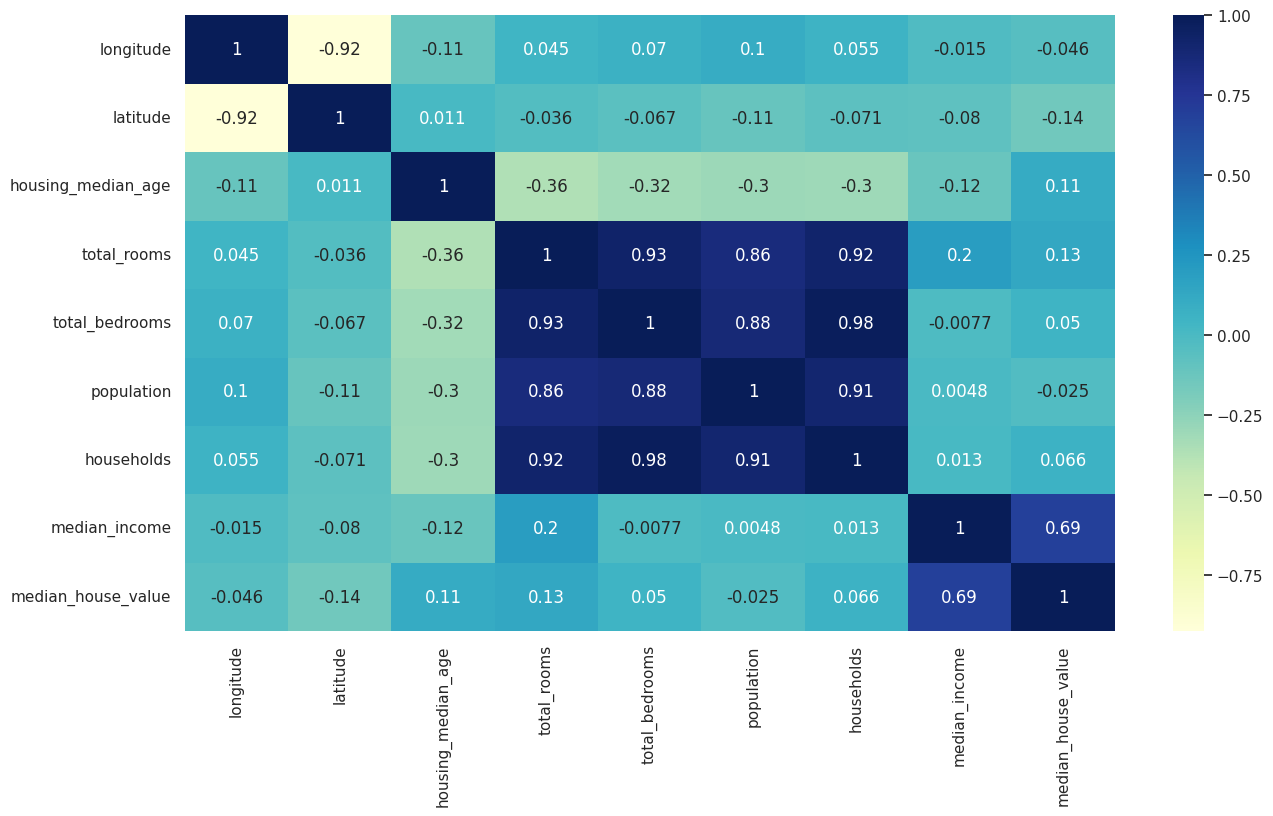

In [12]:
# ANALISIS , nuevas caracteristicas
# correlaciones -> relacion que hay entre todos los datos
data.corr()
#mostrar grafico de las correlaciones
# tamaño
sb.set(rc={'figure.figsize' : (15,8)} )
# designar el grafico "heatmap" cmap -> hace referencia a los colores a mostrar yellow green blue
sb.heatmap(data.corr(), annot=True, cmap="YlGnBu")

In [13]:
# concentracion solamente en la variable que almacena los datos del precio de las casas

data.corr()["median_house_value"].sort_values(ascending=False)

<ipython-input-13-9c7df90619ec>:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  data.corr()["median_house_value"].sort_values(ascending=False)


median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

<Axes: xlabel='median_house_value', ylabel='median_income'>

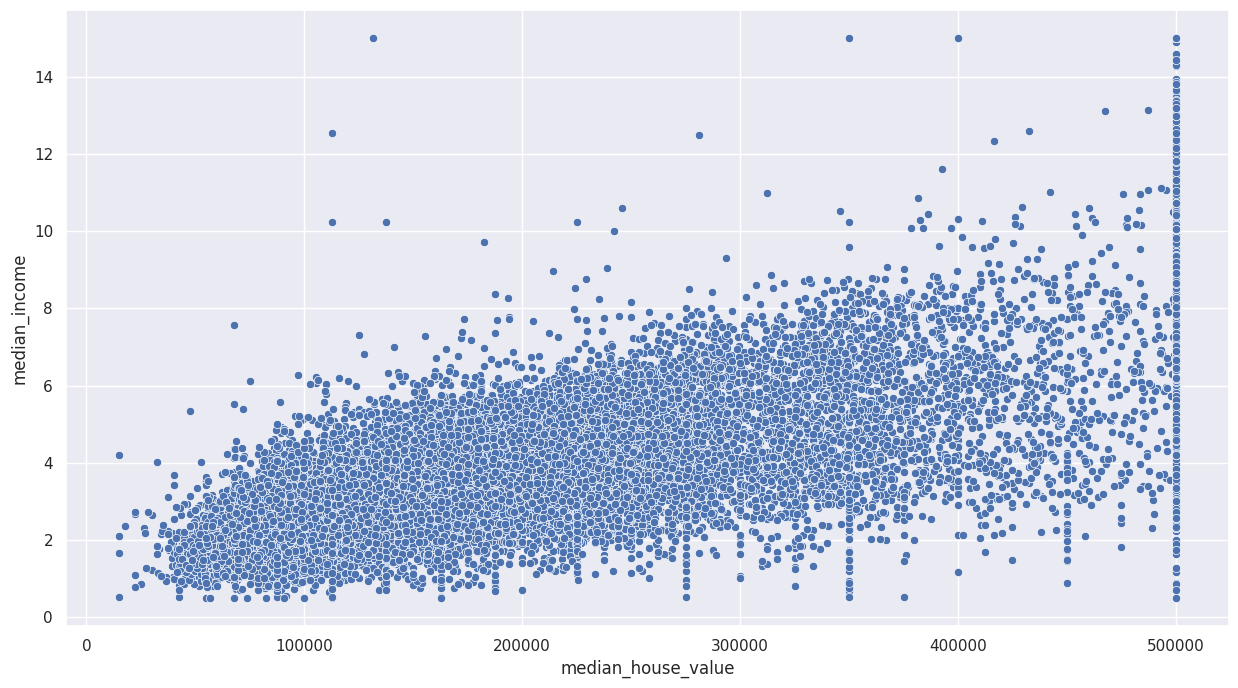

In [14]:
sb.scatterplot(x=datos_na["median_house_value"], y=datos_na["median_income"])

In [15]:
# nuevas caracteristicas

datos_na["bedroom_ratio"] = datos_na["total_bedrooms"] / datos_na["total_rooms"]

<ipython-input-16-0f78ce361bd3>:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  data.corr()
<ipython-input-16-0f78ce361bd3>:6: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sb.heatmap(data.corr(), annot=True, cmap="YlGnBu")


<Axes: >

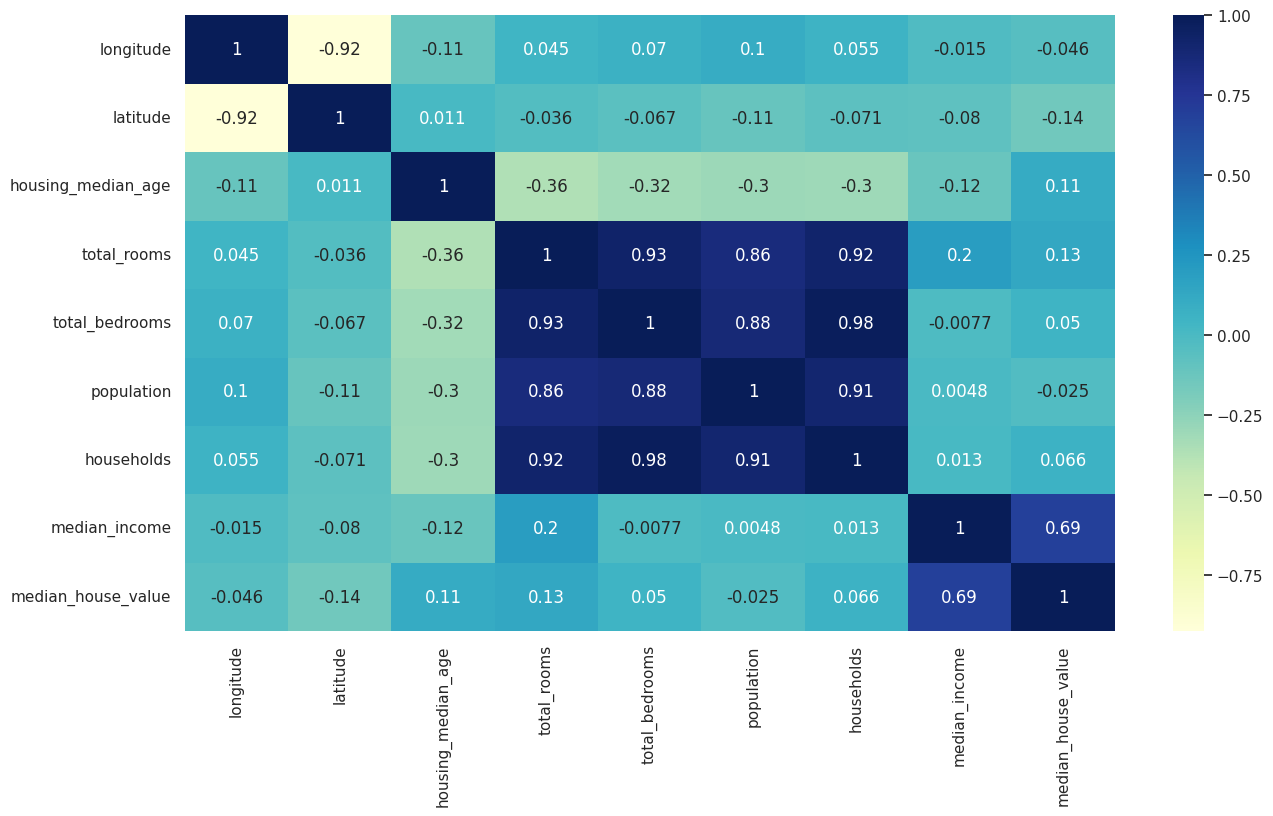

In [16]:
data.corr()
#mostrar grafico de las correlaciones
# tamaño
sb.set(rc={'figure.figsize' : (15,8)} )
# designar el grafico "heatmap" cmap -> hace referencia a los colores a mostrar yellow green blue
sb.heatmap(data.corr(), annot=True, cmap="YlGnBu")

In [17]:
# separar caracteristicas de etiquietas

X = datos_na.drop(["median_house_value"] , axis=1)
y = datos_na["median_house_value"]



In [18]:
# separar los datos en Conjunto de entrenamiento (80%) y Pruebas(20%)

from sklearn.model_selection import train_test_split

X_entrenamiento , X_prueba ,y_entrenamiento , y_prueba = train_test_split(X , y , test_size=0.2)



In [19]:
print("Entrenamiento de X:", X_entrenamiento.shape)
print("Prueba de X:", X_prueba.shape)
print("Entrenamiento de y:", y_entrenamiento.shape)
print("Prueba de y:", y_prueba.shape)

Entrenamiento de X: (16346, 9)
Prueba de X: (4087, 9)
Entrenamiento de y: (16346,)
Prueba de y: (4087,)


In [20]:
# eleccion del modelo
from sklearn.linear_model import LinearRegression

modelo = LinearRegression()



In [21]:
# entrenamiento del modelo
modelo.fit(X_entrenamiento, y_entrenamiento)
predicciones = modelo.predict(X_prueba)

comparativa = {"Prediccion" : predicciones ,  "Valor Real": y_prueba}
pd.DataFrame(comparativa)


,Prediccion,Valor Real
8451,244082.413378,241400.0
121,265102.147769,335000.0
11020,430460.497445,477100.0
15791,255780.167843,162500.0
14512,260625.887488,214600.0
...,...,...
20386,229039.539441,281300.0
641,288536.326957,264700.0
7999,275856.699160,201600.0
2042,143676.306031,121600.0


In [22]:
# overfitting o sobre ajuste -> hace refiere a que se aprende mucho de los datos de entrenamiento, pero luego no puede generalizar los resultados
print(modelo.score(X_entrenamiento, y_entrenamiento))
print(modelo.score(X_prueba , y_prueba))



0.6407822108855336
0.6580519227989655


In [23]:
# ERROR
from sklearn.metrics import mean_squared_error
import numpy as np

msn = mean_squared_error(y_prueba , predicciones)


In [24]:
# obtener raiz cuadrada del error medio cuadratico

rmse = np.sqrt(msn)
rmse


67457.15803023608

In [25]:
# escalamiento -> escalamiento de estos datos
# comprime los datos para que esten todos en un mismo rango y asi el modelo pueda predecir con mejor exactitud
datos_na.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,bedroom_ratio
count,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000
mean,-119.570689,35.633221,28.633094,2636.504233,537.870553,1424.946949,499.433465,3.871162,206864.413155,0.213039
std,2.003578,2.136348,12.591805,2185.269567,421.385070,1133.208490,382.299226,1.899291,115435.667099,0.057983
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000,0.100000
25%,-121.800000,33.930000,18.000000,1450.000000,296.000000,787.000000,280.000000,2.563700,119500.000000,0.175427
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.536500,179700.000000,0.203162
75%,-118.010000,37.720000,37.000000,3143.000000,647.000000,1722.000000,604.000000,4.744000,264700.000000,0.239821
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000,1.000000


In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_ent_esc = scaler.fit_transform(X_entrenamiento)
X_pru_esc = scaler.fit_transform(X_prueba)



In [27]:
pd.DataFrame(X_ent_esc)

,0,1,2,3,4,5,6,7,8
0,-1.194346,1.273302,-0.998336,-0.256351,-0.585731,-0.290399,-0.544346,1.031451,-1.263050
1,-0.819304,1.694491,-1.870948,-0.795002,-0.936524,-0.929285,-0.938855,0.255639,-0.936580
2,0.845886,-0.884122,1.857486,-0.106828,-0.031100,0.651584,0.053949,-0.237491,0.090534
3,-1.454376,0.987829,1.857486,-0.269612,-0.649727,-0.612051,-0.648852,2.237312,-1.456613
4,0.675866,-0.729686,0.191590,-0.544881,-0.320267,0.051578,-0.290920,-0.778918,1.128961
...,...,...,...,...,...,...,...,...,...
16341,0.565854,-0.762445,0.112261,-0.227087,0.137185,-0.076553,0.153229,-0.245646,1.127011
16342,0.690868,-0.870083,0.984873,-0.272813,0.146666,-0.508663,0.085300,-0.680692,1.396232
16343,1.185924,-0.748406,0.588232,-0.192793,-0.422186,-0.429133,-0.442453,0.428363,-0.876701
16344,0.635862,-0.776485,1.540172,0.226056,0.113483,-0.095993,0.014759,-0.181828,-0.449926


In [28]:
# Eliminar los registros que están en el límite
max_age = data['housing_median_age'].max()
max_price = data['median_house_value'].max()
max_income = data['median_income'].max()

data = data[(data['housing_median_age'] != max_age) & (data['median_house_value'] != max_price) & (data['median_income'] != max_income)]

In [30]:
# Hacer predicciones
predicciones = modelo.predict(X_prueba)

# Calcular el error cuadrático medio
mse = mean_squared_error(y_prueba, predicciones)
rmse = np.sqrt(mse)

print("Root Mean Squared Error: ", rmse)

Root Mean Squared Error:  67457.15803023608


<Axes: >

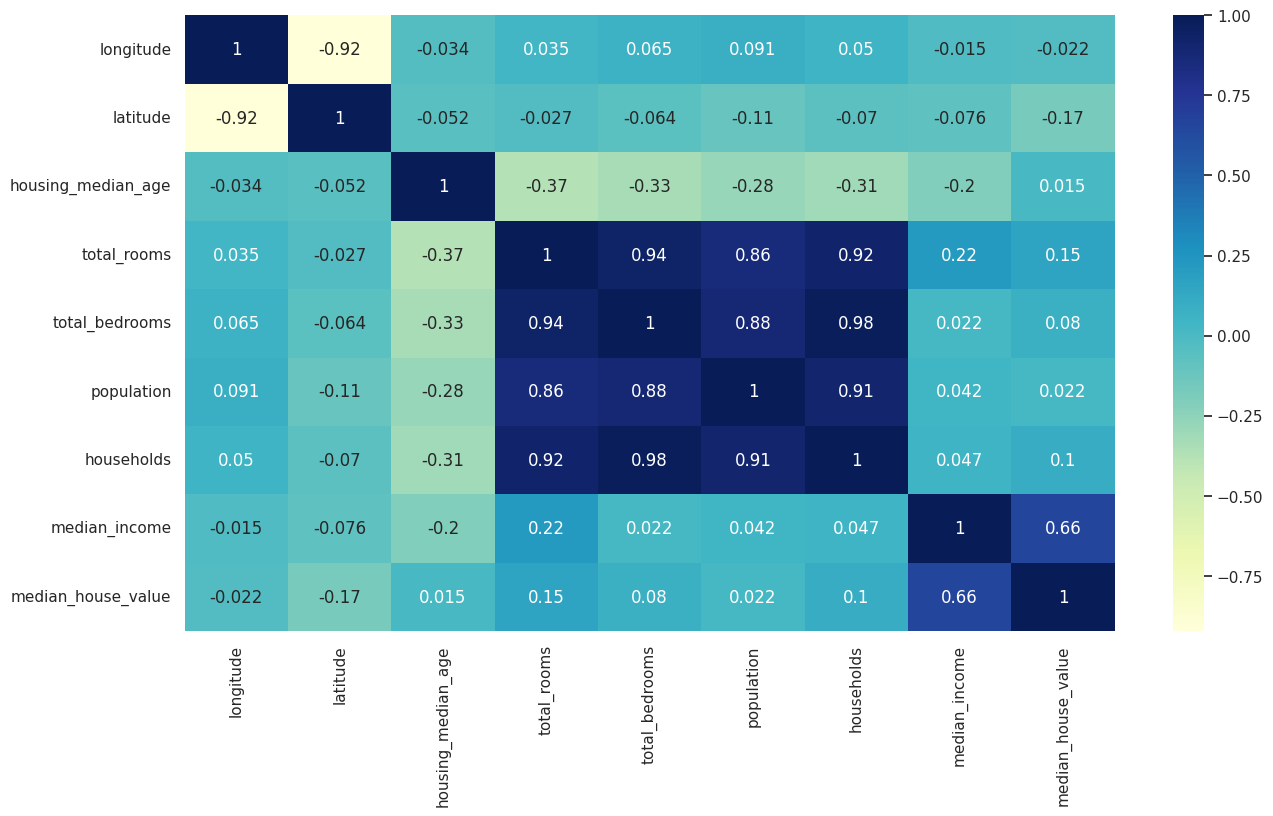

In [31]:
data.corr()
#mostrar grafico de las correlaciones
# tamaño
sb.set(rc={'figure.figsize' : (15,8)} )
# designar el grafico "heatmap" cmap -> hace referencia a los colores a mostrar yellow green blue
sb.heatmap(data.corr(), annot=True, cmap="YlGnBu")

<Axes: xlabel='median_house_value', ylabel='median_income'>

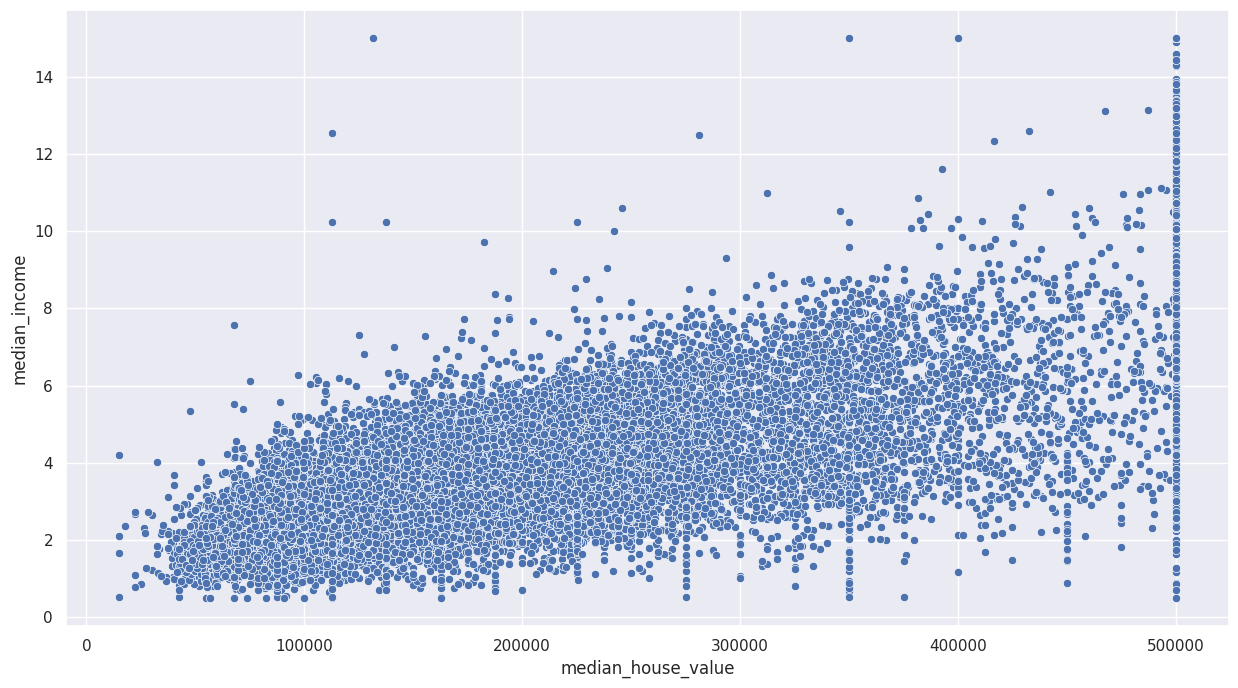

In [32]:
sb.scatterplot(x=datos_na["median_house_value"], y=datos_na["median_income"])